# 22. ARC-AGI-1: 격자 생각 위성

ARC는 색칠된 격자 퍼즐이야. 예시 2–5쌍을 보고 규칙을 찾아서 새 격자에 적용해야 해.

- 채점은 ARC 공식대로: 테스트 입력마다 **기회 2번**, 격자 전체가 **정확히** 같아야 맞음.
- 개발용은 training 앞 100개, 봉인 시험(final)은 evaluation 400개 전부. evaluation은 MK1을 얼리고 판정 규칙을 먼저 적은 다음 **한 번만** 열었어.

**시험 본 셋**
- **E2B 혼자 / E4B 혼자**: Gemma 4가 숫자 줄로 된 격자를 보고 풀이를 쓴 다음 `ANSWER:` 뒤에 격자를 내. 기회 1은 온도 0, 기회 2는 온도 0.7.
- **MK1**: **생각 위성**(신경망 없음)이 먼저 생각해. 격자 기본 동작 약 90개를 3단계까지 조합하고, 같은 모양 과제엔 이웃 규칙 학습기도 써. **모든 예시를 정확히 다시 만들어 내는 프로그램**을 찾았을 때만 답하고, 못 찾으면 입을 다물어. 답이 2개보다 적으면 **말하기 위성**(E2B)의 저장된 답으로 남은 기회를 채워.

자세한 설명과 판정 규칙: `design/mk1-v2-spec.md` 12절. 여기선 저장된 결과 파일만 읽어서 그려.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from cognitive_lab import summary_arc as A
from cognitive_lab import viz as V
V.setup()
COLOR = {"e2b": V.NEUTRAL, "e4b": V.ORANGE, "mk1": V.AQUA}
LABEL = dict(A.SYSTEMS)
systems = [s for s, _ in A.SYSTEMS]
vd = {p: A.verdict(p) for p in ("dev", "final")}
for p, v in vd.items():
    print(p.ljust(5), v["tasks"], "tasks |", " | ".join(f"{LABEL[s]} {v['score'][s]:.4f}" for s in systems))
    for k, d in v["versus"].items():
        print("      ", k.upper(), f"{d['difference']:+.4f}  ({d['ci95'][0]:+.4f}, {d['ci95'][1]:+.4f})")
    print("       생각 위성: 답함", v["search"]["answered"], "| 답했을 때 맞음", v["search"]["right_when_answered"])

dev   100 tasks | E2B 혼자 0.0400 | E4B 혼자 0.0700 | MK1 0.2500
       MK1 - E2B +0.2100  (+0.1300, +0.3000)
       MK1 - E4B +0.1800  (+0.1000, +0.2700)
       생각 위성: 답함 21 | 답했을 때 맞음 1.0
final 400 tasks | E2B 혼자 0.0088 | E4B 혼자 0.0225 | MK1 0.0737
       MK1 - E2B +0.0650  (+0.0425, +0.0900)
       MK1 - E4B +0.0512  (+0.0250, +0.0788)
       생각 위성: 답함 28 | 답했을 때 맞음 0.9286


## 1. 봉인 시험 결과 한눈에

왼쪽은 evaluation 400개 점수, 오른쪽은 차이(MK1 − 상대)와 과제 단위 짝지은 부트스트랩 95% 구간이야. 주 가설은 "MK1 − E4B > 0 (구간 하한 > 0)"이었어.

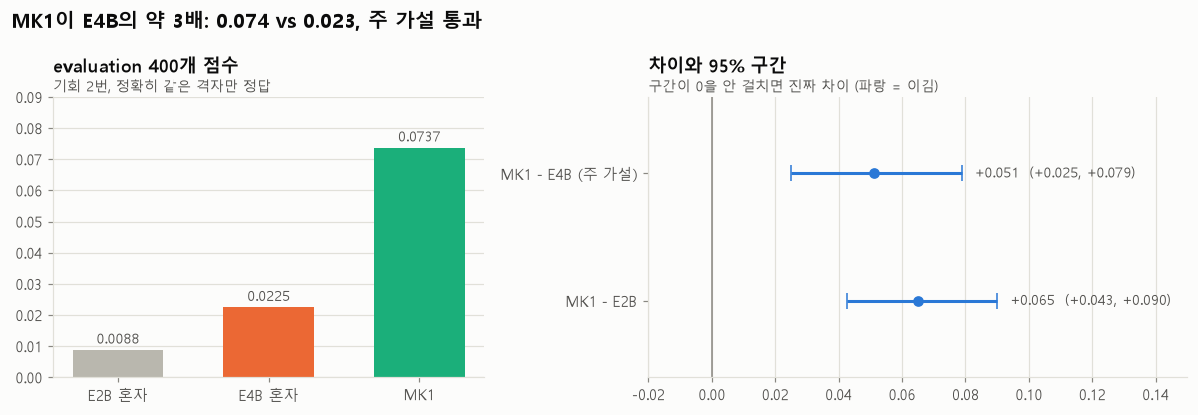

In [2]:
v = vd["final"]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.25]})
vals = [v["score"][s] for s in systems]
ax.bar(range(3), vals, color=[COLOR[s] for s in systems], width=0.6)
for i, x in enumerate(vals):
    ax.text(i, x + 0.002, f"{x:.4f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
ax.set_xticks(range(3), [LABEL[s] for s in systems]); ax.set_ylim(0, 0.09); ax.grid(axis="x", visible=False)
ax.set_title("evaluation 400개 점수", pad=16)
V.note(ax, "기회 2번, 정확히 같은 격자만 정답")
pairs = [("mk1 - e4b", "MK1 - E4B (주 가설)"), ("mk1 - e2b", "MK1 - E2B")]
for i, (k, name) in enumerate(pairs):
    d, (lo, hi) = v["versus"][k]["difference"], v["versus"][k]["ci95"]
    bx.errorbar(d, i, xerr=[[d - lo], [hi - d]], fmt="o", color=V.BLUE if lo > 0 else V.MUTED, capsize=5, lw=2)
    bx.text(hi + 0.004, i, f"{d:+.3f}  ({lo:+.3f}, {hi:+.3f})", va="center", fontsize=9, color=V.TEXT_SECONDARY)
bx.axvline(0, color=V.MUTED, lw=1)
bx.set_yticks(range(2), [n for _, n in pairs]); bx.set_ylim(1.6, -0.6)
bx.set_xlim(-0.02, 0.15); bx.grid(axis="y", visible=False)
bx.set_title("차이와 95% 구간", pad=16)
V.note(bx, "구간이 0을 안 걸치면 진짜 차이 (파랑 = 이김)")
fig.suptitle("MK1이 E4B의 약 3배: 0.074 vs 0.023, 주 가설 통과", x=0.01, ha="left", fontsize=13, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()

## 2. 개발용 vs 봉인 시험

생각 위성의 기본 동작은 **개발용(training) 실패를 보면서** 만들었어. 그래서 개발용 수치는 낙관적이고, evaluation은 원래 training보다 훨씬 어렵다고 알려져 있어. 떨어지는 건 예상했던 일이야(예상: MK1 0.06–0.12, E4B 0.02–0.05).

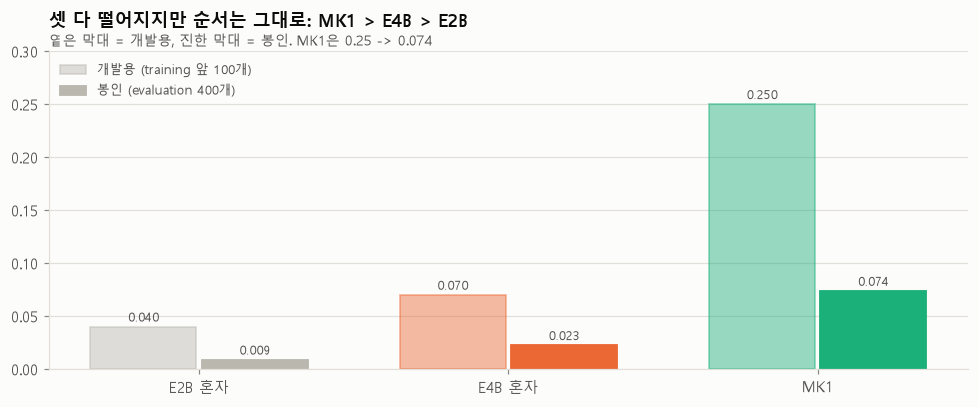

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(3); w = 0.36
for j, (p, name, alpha) in enumerate([("dev", "개발용 (training 앞 100개)", 0.45), ("final", "봉인 (evaluation 400개)", 1.0)]):
    vals = [vd[p]["score"][s] for s in systems]
    ax.bar(x + (j - 0.5) * w, vals, width=w * 0.95, color=[COLOR[s] for s in systems], alpha=alpha,
           edgecolor=[COLOR[s] for s in systems], linewidth=1.2, label=name)
    for xi, val in zip(x, vals):
        ax.text(xi + (j - 0.5) * w, val + 0.005, f"{val + 1e-9:.3f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [LABEL[s] for s in systems]); ax.set_ylim(0, 0.3); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("셋 다 떨어지지만 순서는 그대로: MK1 > E4B > E2B", pad=16)
V.note(ax, "옅은 막대 = 개발용, 진한 막대 = 봉인. MK1은 0.25 -> 0.074")
fig.tight_layout(); plt.show()

## 3. MK1의 점수는 어디서 왔어?

MK1 점수는 두 군데서 와: 생각 위성이 직접 맞힌 것, 그리고 생각 위성이 조용할 때 말하기 위성(E2B)의 답으로 채운 것. 테스트 입력마다 생각 위성의 답이 맞으면 생각 위성 몫, 아니면 채운 답이 맞을 때 채움 몫으로 셌어. 오른쪽은 과제 단위로, 누가 푼 과제가 겹치는지 본 거야.

생각 위성 몫 0.06500 + 채움 몫 0.00875 = 0.07375 (판정 파일엔 0.0737로 반올림)


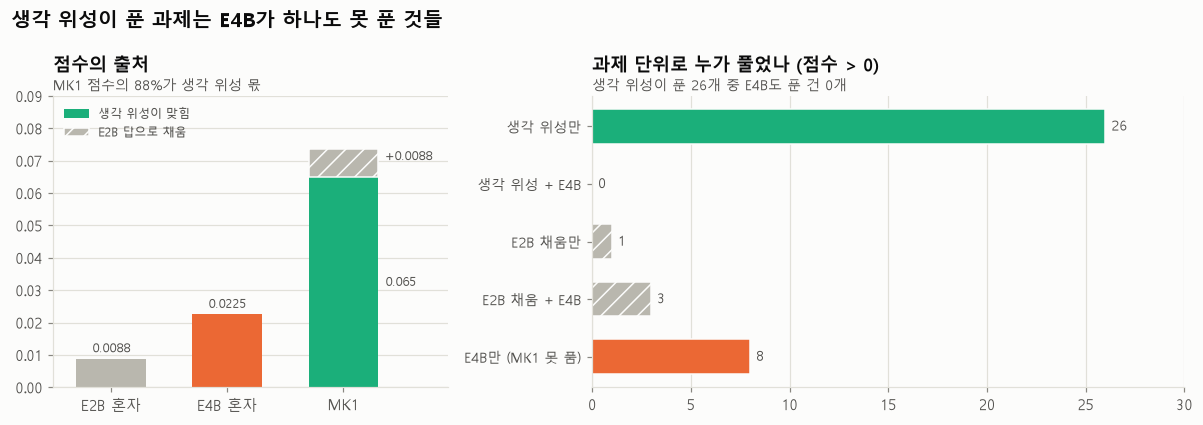

In [4]:
src = A.sources("final")
n = len(src)
search_pts = sum(s["search"] for s in src.values()) / n
fill_pts = sum(s["fill"] for s in src.values()) / n
S = {t for t, s in src.items() if s["search"] > 0}
F = {t for t, s in src.items() if s["fill"] > 0}
E4 = A.solved("e4b", "final")
print(f"생각 위성 몫 {search_pts:.5f} + 채움 몫 {fill_pts:.5f} = {search_pts + fill_pts:.5f} (판정 파일엔 0.0737로 반올림)")
groups = [("생각 위성만", len(S - E4), V.AQUA), ("생각 위성 + E4B", len(S & E4), V.AQUA),
          ("E2B 채움만", len(F - E4 - S), V.NEUTRAL), ("E2B 채움 + E4B", len(F & E4 - S), V.NEUTRAL),
          ("E4B만 (MK1 못 품)", len(E4 - S - F), V.ORANGE)]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={"width_ratios": [1, 1.5]})
names = ["E2B 혼자", "E4B 혼자", "MK1"]
ax.bar(0, vd["final"]["score"]["e2b"], color=V.NEUTRAL, width=0.6)
ax.bar(1, vd["final"]["score"]["e4b"], color=V.ORANGE, width=0.6)
ax.bar(2, search_pts, color=V.AQUA, width=0.6, label="생각 위성이 맞힘")
ax.bar(2, fill_pts, bottom=search_pts, color=V.NEUTRAL, width=0.6, hatch="//", edgecolor=V.SURFACE, label="E2B 답으로 채움")
ax.text(2.36, search_pts / 2, f"{search_pts:.3f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.text(2.36, search_pts + fill_pts / 2 + 0.002, f"+{fill_pts:.4f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
for i, s in enumerate(["e2b", "e4b"]):
    ax.text(i, vd["final"]["score"][s] + 0.002, f"{vd['final']['score'][s]:.4f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_xticks(range(3), names); ax.set_xlim(-0.5, 2.9); ax.set_ylim(0, 0.09); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8, loc="upper left")
ax.set_title("점수의 출처", pad=16)
V.note(ax, f"MK1 점수의 {search_pts / (search_pts + fill_pts):.0%}가 생각 위성 몫")
for i, (name, c, color) in enumerate(groups):
    bx.barh(i, c, color=color, height=0.6, hatch="//" if "채움" in name else None, edgecolor=V.SURFACE)
    bx.text(c + 0.3, i, str(c), va="center", fontsize=9, color=V.TEXT_SECONDARY)
bx.set_yticks(range(len(groups)), [g[0] for g in groups], fontsize=9); bx.invert_yaxis()
bx.set_xlim(0, 30); bx.grid(axis="y", visible=False)
bx.set_title("과제 단위로 누가 풀었나 (점수 > 0)", pad=16)
V.note(bx, f"생각 위성이 푼 {len(S)}개 중 E4B도 푼 건 {len(S & E4)}개")
fig.suptitle("생각 위성이 푼 과제는 E4B가 하나도 못 푼 것들", x=0.01, ha="left", fontsize=13, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()

## 4. 생각 위성의 판단: 모르면 안 한다

생각 위성은 예시를 전부 다시 만들어 내는 프로그램을 찾았을 때만 답해. 부 가설은 "답했을 때 맞는 비율 ≥ 0.9"였어. 대부분 과제에선 조용했고, 답할 땐 거의 맞았어.

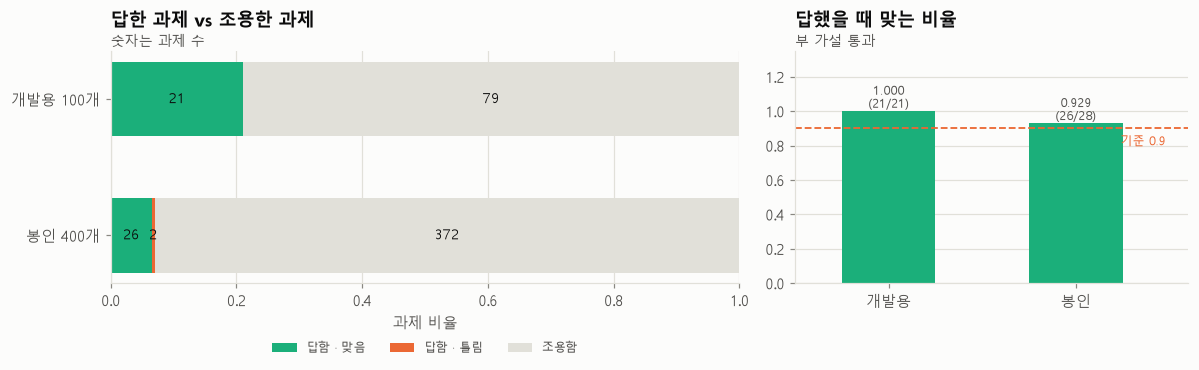

봉인에서 틀린 2개: ['6ea4a07e', '9ddd00f0']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
for i, p in enumerate(["dev", "final"]):
    j = A.search_judgement(p)
    left = 0
    for key, name, color in [("right", "답함 · 맞음", V.AQUA), ("wrong", "답함 · 틀림", V.ORANGE), ("silent", "조용함", V.GRID)]:
        share = j[key] / j["tasks"]
        ax.barh(i, share, left=left, color=color, height=0.55, label=name if i == 0 else None)
        if j[key]:
            ax.text(left + share / 2, i, str(j[key]), ha="center", va="center", fontsize=9, color=V.TEXT)
        left += share
ax.set_yticks([0, 1], ["개발용 100개", "봉인 400개"]); ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_xlabel("과제 비율"); ax.grid(axis="y", visible=False)
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2))
ax.set_title("답한 과제 vs 조용한 과제", pad=16)
V.note(ax, "숫자는 과제 수")
bx = axes[1]
prec = [A.search_judgement(p) for p in ("dev", "final")]
vals = [j["right"] / j["answered"] for j in prec]
bx.bar([0, 1], vals, color=V.AQUA, width=0.5)
for i, (val, j) in enumerate(zip(vals, prec)):
    bx.text(i, val + 0.02, f"{val:.3f}\n({j['right']}/{j['answered']})", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
bx.axhline(0.9, color=V.ORANGE, lw=1.2, ls="--")
bx.text(1.48, 0.86, "기준 0.9", va="top", ha="right", fontsize=8, color=V.ORANGE)
bx.set_xticks([0, 1], ["개발용", "봉인"]); bx.set_ylim(0, 1.35); bx.set_xlim(-0.5, 1.6); bx.grid(axis="x", visible=False)
bx.set_title("답했을 때 맞는 비율", pad=16)
V.note(bx, "부 가설 통과")
fig.tight_layout(); plt.show()
print("봉인에서 틀린 2개:", prec[1]["wrong_ids"])

틀린 2개(`6ea4a07e`, `9ddd00f0`)는 길게 조합된 프로그램이 우연히 예시에 다 맞아떨어진 경우야. 예시가 2–5쌍뿐이라 긴 프로그램일수록 이런 우연이 생길 수 있어.

## 5. 어떤 프로그램이 봉인 과제를 풀었어?

생각 위성이 답한 과제마다 첫 번째 프로그램(기회 1을 만든 것)을 셌어. `>`는 왼쪽부터 차례로 적용한다는 뜻이야. 틀린 2개는 주황으로 같이 넣었어.

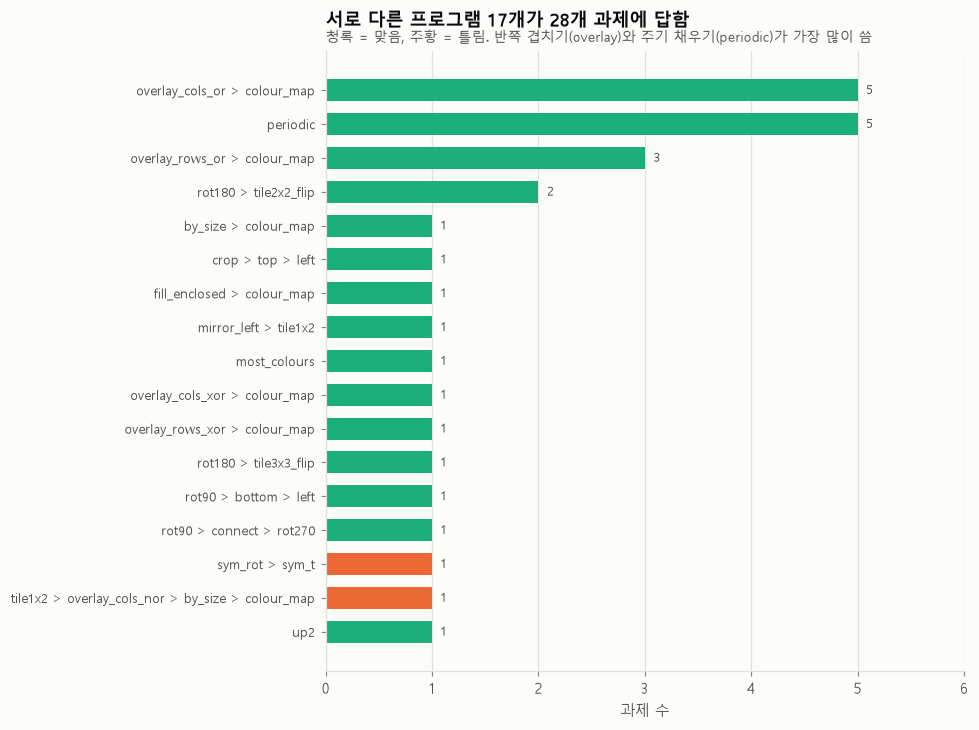

In [6]:
right = A.programs("final", only_right=True)
every = A.programs("final", only_right=False)
wrong = every - right
rows = sorted(every, key=lambda p: (-every[p], p))[:25]
fig, ax = plt.subplots(figsize=(9, 0.32 * len(rows) + 1.3))
for i, p in enumerate(rows):
    ax.barh(i, right[p], color=V.AQUA, height=0.65)
    ax.barh(i, wrong[p], left=right[p], color=V.ORANGE, height=0.65)
    ax.text(every[p] + 0.08, i, str(every[p]), va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yticks(range(len(rows)), rows, fontsize=8.5); ax.invert_yaxis()
ax.set_xlim(0, max(every.values()) + 1); ax.xaxis.get_major_locator().set_params(integer=True)
ax.grid(axis="y", visible=False); ax.set_xlabel("과제 수")
ax.set_title(f"서로 다른 프로그램 {len(every)}개가 {sum(every.values())}개 과제에 답함", pad=16)
V.note(ax, "청록 = 맞음, 주황 = 틀림. 반쪽 겹치기(overlay)와 주기 채우기(periodic)가 가장 많이 씀")
fig.tight_layout(); plt.show()

## 6. 공정성 기록: Gemma가 낸 답이 격자였나?

Gemma에겐 풀이를 쓸 자리(최대 3,000토큰)를 줬지만, 답의 절반 정도는 채점할 수 있는 격자가 아니었어(토큰 안에 풀이를 못 끝내거나 줄 길이가 들쭉날쭉). 격자가 아니면 틀린 걸로 쳤어. 프롬프트가 너무 길어서 못 준 과제는 0개였어. 생각 모드를 켜면 더 나을 수도 있지만 시간이 몇 배 들어.

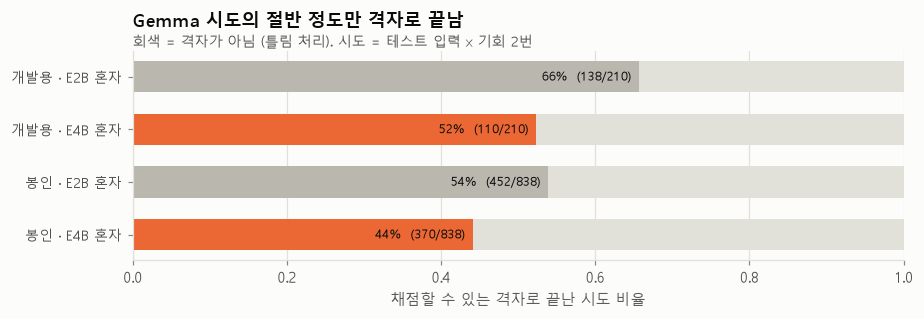

E2B 혼자 봉인 비용: 호출 838번, 5.1시간
E4B 혼자 봉인 비용: 호출 838번, 8.9시간


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 3.0))
rows = [(p, s) for p in ("dev", "final") for s in ("e2b", "e4b")]
for i, (p, s) in enumerate(rows):
    h = A.format_health(s, p)
    share = h["grids"] / h["attempts"]
    ax.barh(i, share, color=COLOR[s], height=0.6)
    ax.barh(i, 1 - share, left=share, color=V.GRID, height=0.6)
    ax.text(share - 0.01, i, f"{share:.0%}  ({h['grids']}/{h['attempts']})", ha="right", va="center", fontsize=8.5, color=V.TEXT)
names = {"dev": "개발용", "final": "봉인"}
ax.set_yticks(range(len(rows)), [f"{names[p]} · {LABEL[s]}" for p, s in rows], fontsize=9); ax.invert_yaxis()
ax.set_xlim(0, 1); ax.grid(axis="y", visible=False); ax.set_xlabel("채점할 수 있는 격자로 끝난 시도 비율")
ax.set_title("Gemma 시도의 절반 정도만 격자로 끝남", pad=16)
V.note(ax, "회색 = 격자가 아님 (틀림 처리). 시도 = 테스트 입력 x 기회 2번")
fig.tight_layout(); plt.show()
for s in ("e2b", "e4b"):
    c = A.summary(s, "final")["cost"]
    print(LABEL[s], f"봉인 비용: 호출 {c['calls']}번, {c['seconds'] / 3600:.1f}시간")

## 7. 예시: 생각 위성은 풀고 E4B는 못 푼 과제

작은 과제 몇 개를 ARC 표준 10색으로 그렸어. 위 줄은 예시 쌍, 아래 줄은 테스트 입력, 정답, MK1의 첫 번째 답이야.

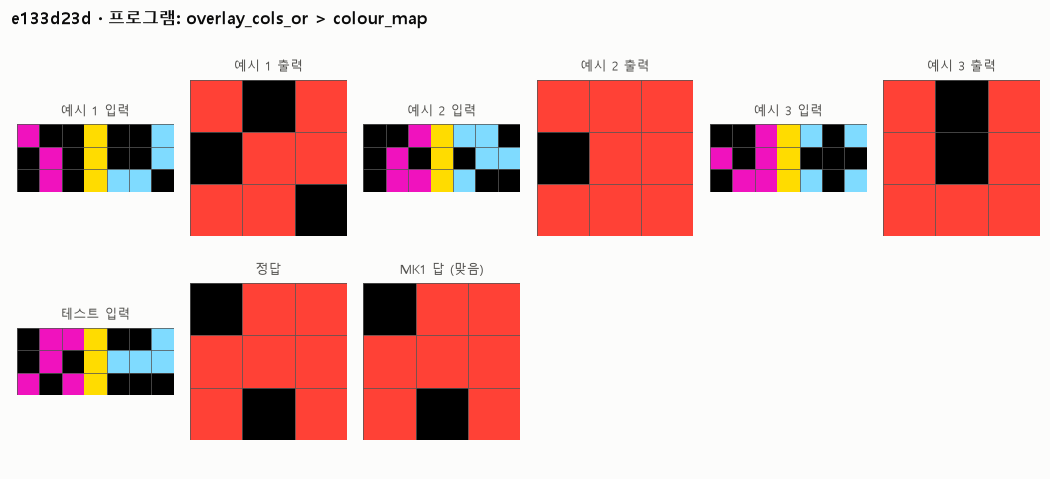

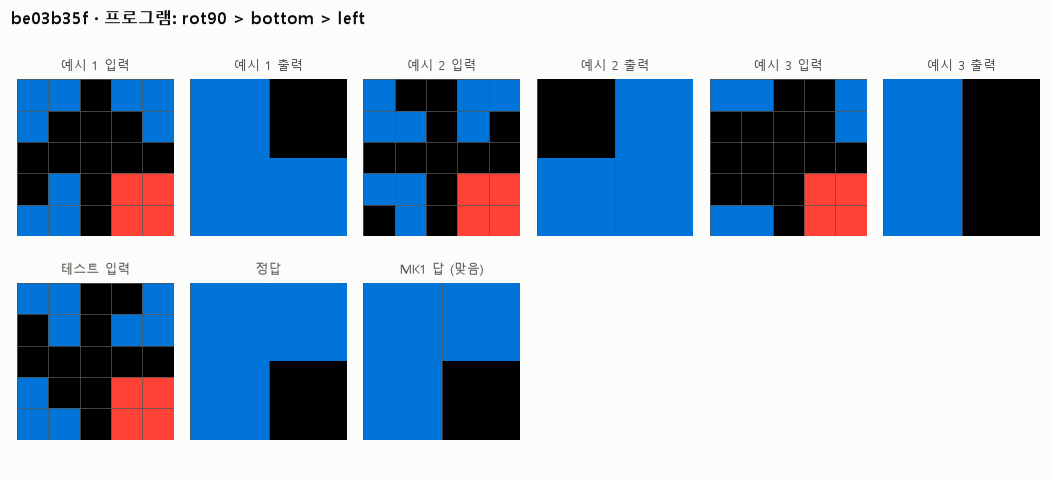

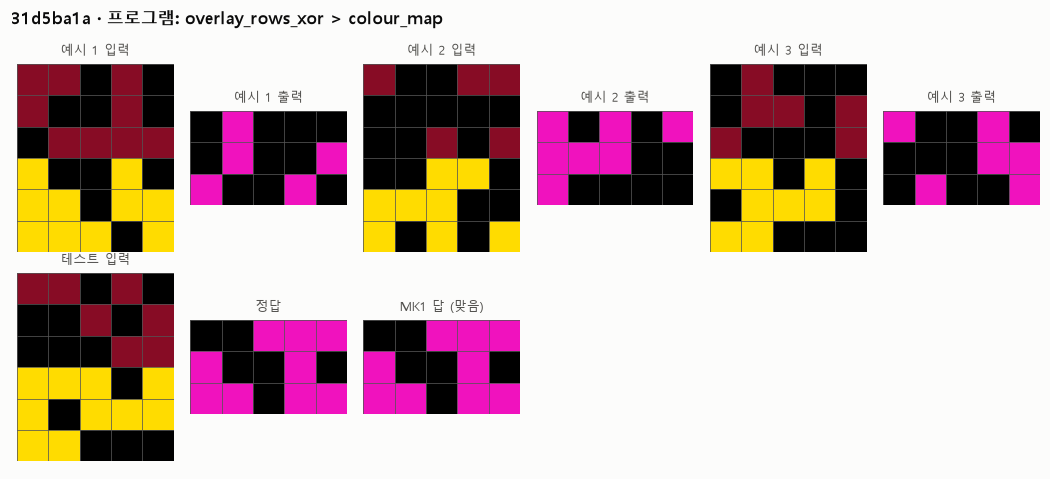

In [8]:
CMAP = ListedColormap(A.PALETTE)

def draw(ax, g, title):
    g = np.array(g)
    ax.imshow(g, cmap=CMAP, vmin=0, vmax=9)
    ax.set_xticks(np.arange(-0.5, g.shape[1]), minor=True); ax.set_yticks(np.arange(-0.5, g.shape[0]), minor=True)
    ax.grid(which="minor", color="#555555", lw=0.5); ax.grid(which="major", visible=False)
    ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(title, fontsize=8.5, fontweight="normal", color=V.TEXT_SECONDARY, loc="center")

for ex in A.examples("final", n=3):
    t = ex["task"]
    k = min(len(t["train"]), 3)
    cols = max(2 * k, 3)
    fig, axes = plt.subplots(2, cols, figsize=(1.6 * cols, 4.4))
    for ax in axes.ravel():
        ax.axis("off")
    for i, pair in enumerate(t["train"][:k]):
        for j, key in enumerate(("input", "output")):
            axes[0, 2 * i + j].axis("on")
            draw(axes[0, 2 * i + j], pair[key], f"예시 {i + 1} {'입력' if key == 'input' else '출력'}")
    test = t["test"][0]
    for j, (g, name) in enumerate([(test["input"], "테스트 입력"), (test["output"], "정답"), (ex["answer"][0], "MK1 답 (맞음)")]):
        axes[1, j].axis("on")
        draw(axes[1, j], g, name)
    fig.suptitle(f"{ex['id']} · 프로그램: {ex['program']}", x=0.01, ha="left", fontsize=11, fontweight="bold", color=V.TEXT)
    fig.tight_layout(); plt.show()

## 정리

- **주 가설 통과**: evaluation 400개에서 MK1 0.074, E4B 0.023, E2B 0.009. MK1 − E4B = +0.051, 구간 (+0.025, +0.079).
- **부 가설 통과**: 생각 위성은 400개 중 28개에만 답했고 26개 맞음(0.929 ≥ 0.9). 모르면 조용히 있었어.
- 점수의 대부분(0.065)은 생각 위성 몫이고, 생각 위성이 푼 26개는 E4B가 하나도 못 푼 과제야.
- 개발용(0.25)에서 크게 떨어졌어. evaluation이 어렵고, 기본 동작을 개발용을 보며 만들었으니까. 절대 점수(7.4%)는 낮아.
- spec 12절의 교훈: 계산을 더 쓰는 건 **정확한 검증기가 있을 때만** 이득이야. ARC에선 "예시를 다시 돌려 보기"가 그 검증기였어. 다음은 손으로 만든 기본 동작을 경험에서 넓히는 거야.